In [1]:
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

import  os
import  json
import  joblib
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.ensemble import RandomForestRegressor

OUTPUT_FOLDER = "RF_Pbubble_OUTPUTS"

In [2]:
df = pd.read_csv("../interfacial_results_dataset_A1.csv")

print(f"Total samples: {len(df)}")
print(f"\nP_bubble statistics:")
print(df["P_bubble"].describe())

Total samples: 19171

P_bubble statistics:
count    19171.000000
mean        38.270487
std         20.467106
min          3.181219
25%         21.341211
50%         35.985782
75%         54.333096
max        108.401596
Name: P_bubble, dtype: float64


In [3]:
target     = "P_bubble"
SEED       = 50015
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13419
Testing samples:    2876
Validation samples: 2876


Feature correlations with P_bubble:
pressure              0.854181
z_hydrogen            0.648953
temperature           0.634219
z_nitrogen            0.062354
z_carbon monoxide     0.054728
z_oxygen             -0.035170
z_argon              -0.058853
z_methane            -0.094578
z_hydrogen sulfide   -0.101637
z_carbon dioxide     -0.309526
Name: P_bubble, dtype: float64


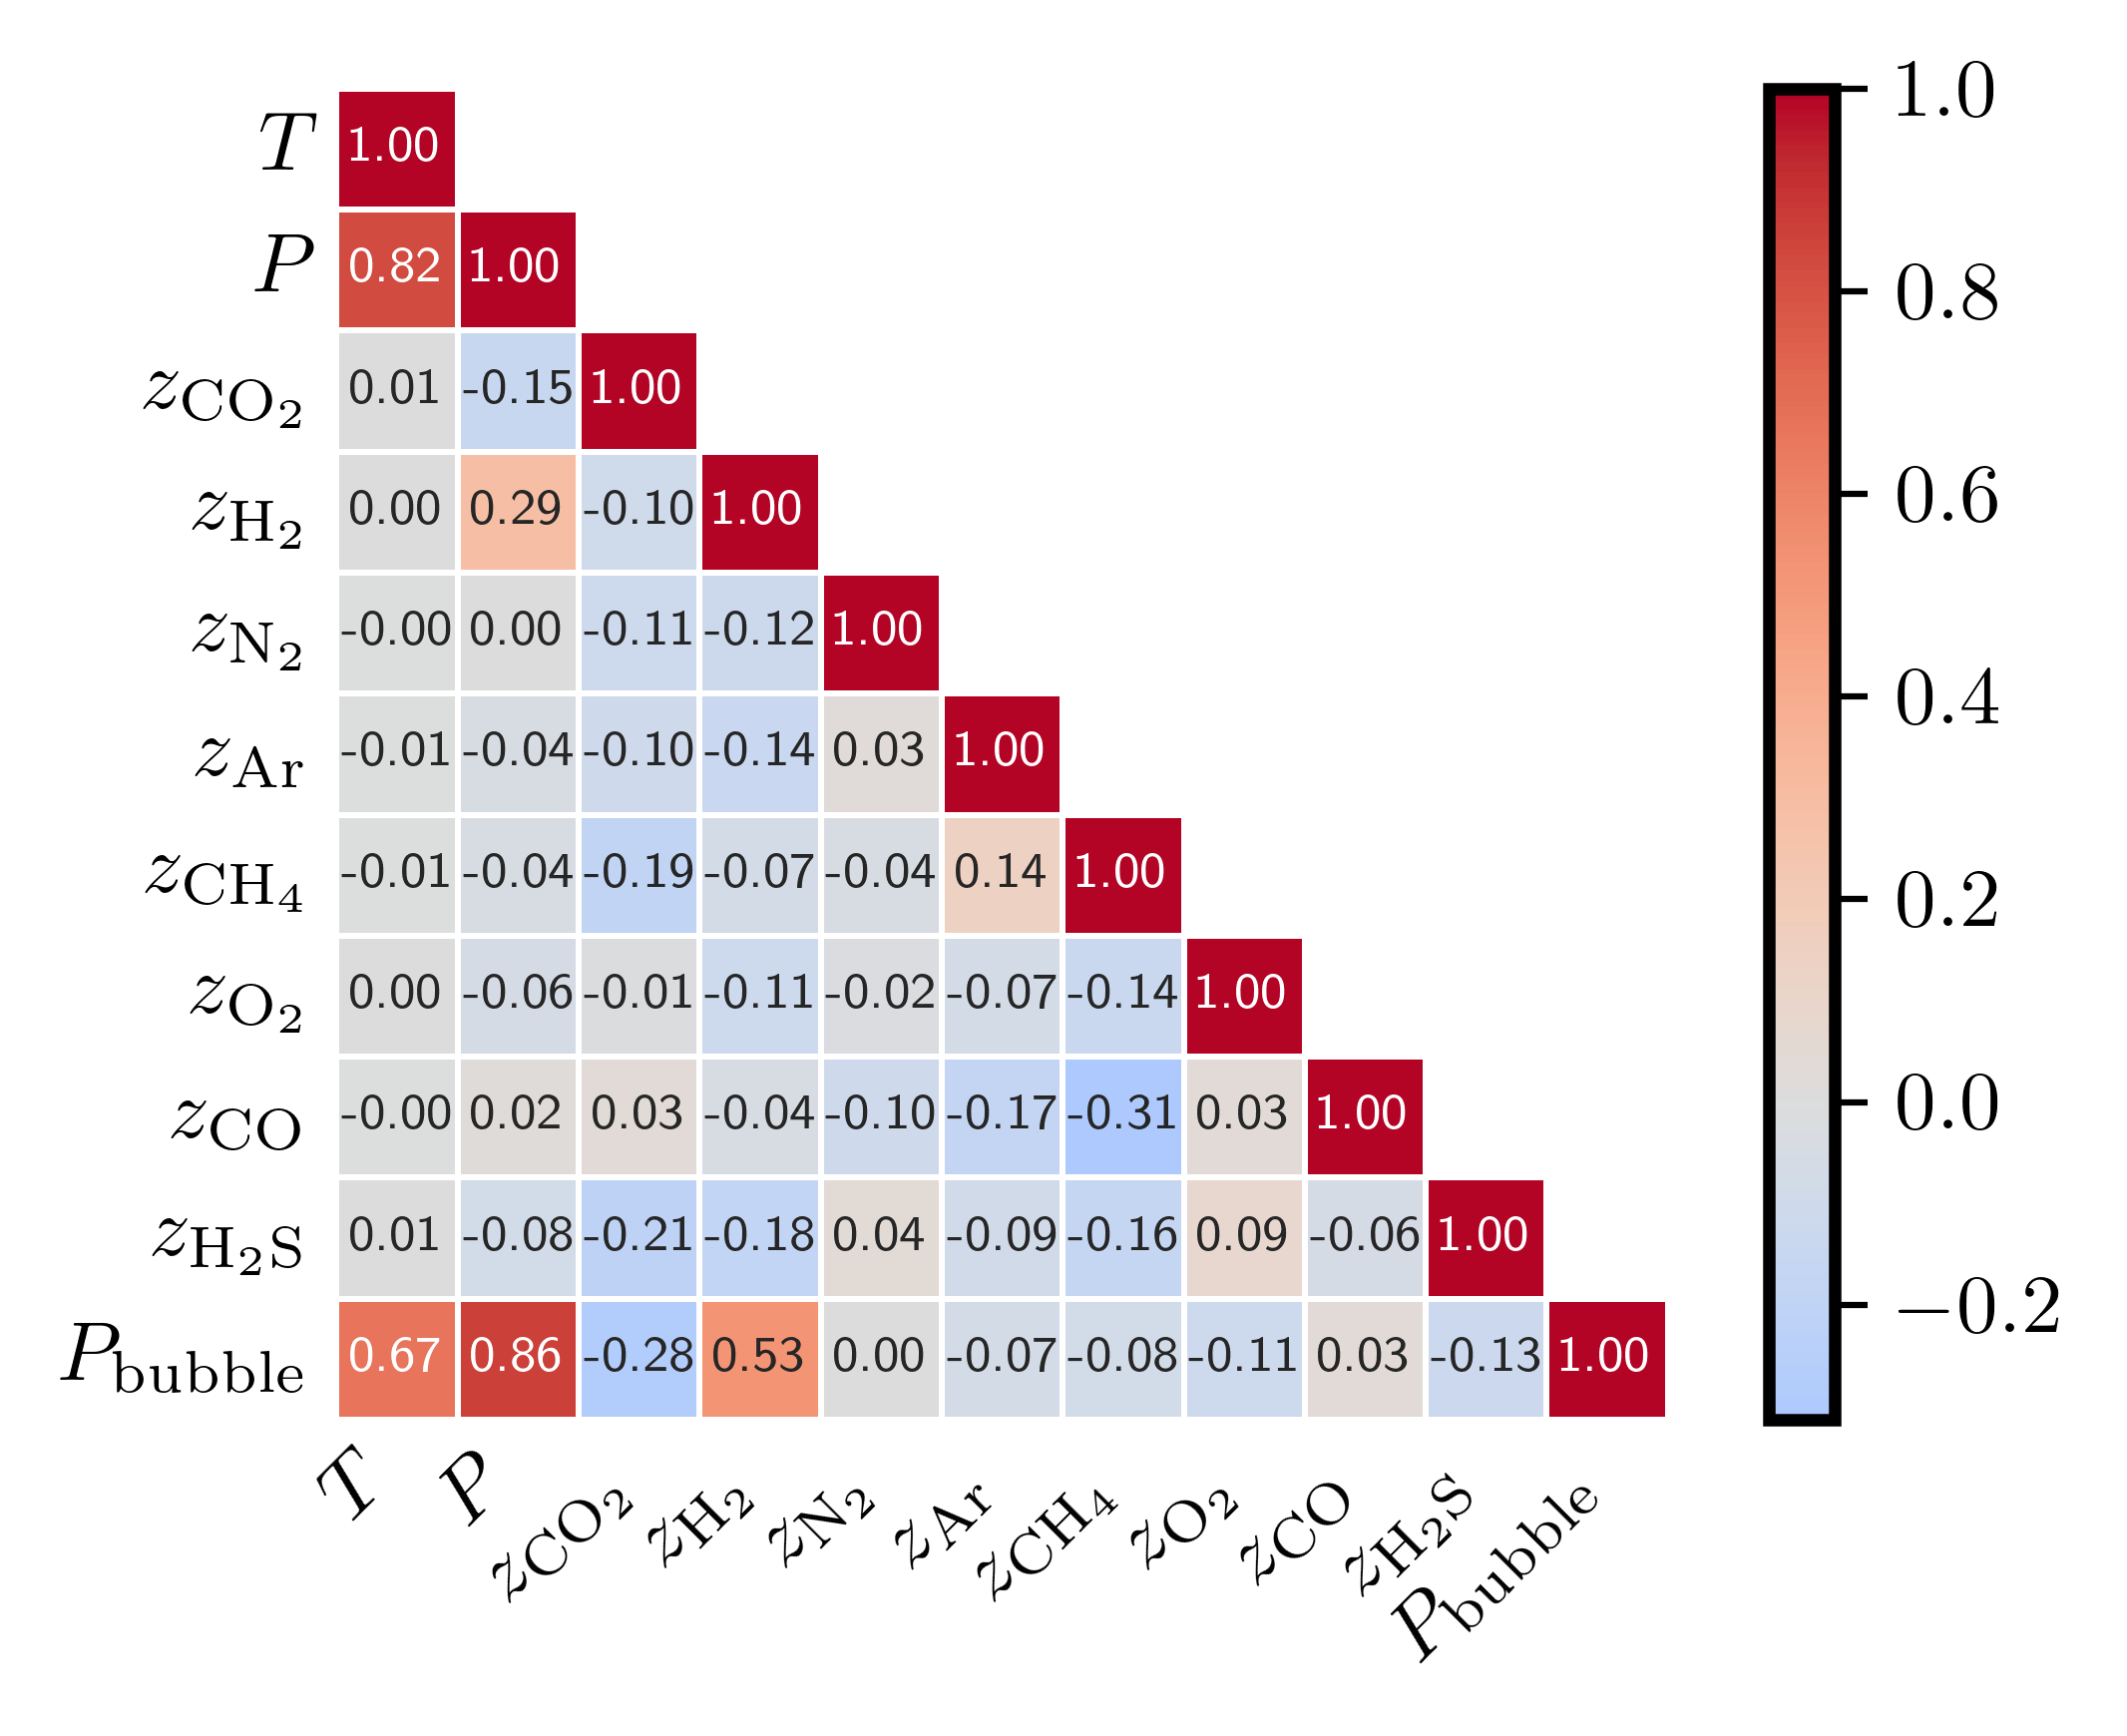

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [4]:
plot_correlation_heatmap(df, features, target, save_path="RF_P_bubble_correlation", folder=OUTPUT_FOLDER)

In [5]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred    = rf_model.predict(X_train)
y_test_pred     = rf_model.predict(X_test)
y_val_pred      = rf_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_bubble

Training Set:
  R²:   0.999648
  RMSE: 0.383997 bar
  MAE:  0.238773 bar

Test Set:
  R²:   0.997360
  RMSE: 1.052246 bar
  MAE:  0.653385 bar

Validation Set:
  R²:   0.997672
  RMSE: 0.987722 bar
  MAE:  0.629265 bar


In [6]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19171 rows
Model saved to: RF_Pbubble_OUTPUTS/RF_P_bubble_model.joblib


In [7]:
# 5-fold cross-validation
cv_r2_scores   = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
cv_rmse_scores = -cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")

Cross-Validation R² Scores:   [0.94281949 0.96794398 0.94409125 0.97766336 0.97551558]
Mean CV R²:   0.961607 (+/- 0.030347)

Cross-Validation RMSE Scores: [4.81620768 3.28264717 4.466943   3.36239982 3.28297932]
Mean CV RMSE: 3.842235 (+/- 1.325151)


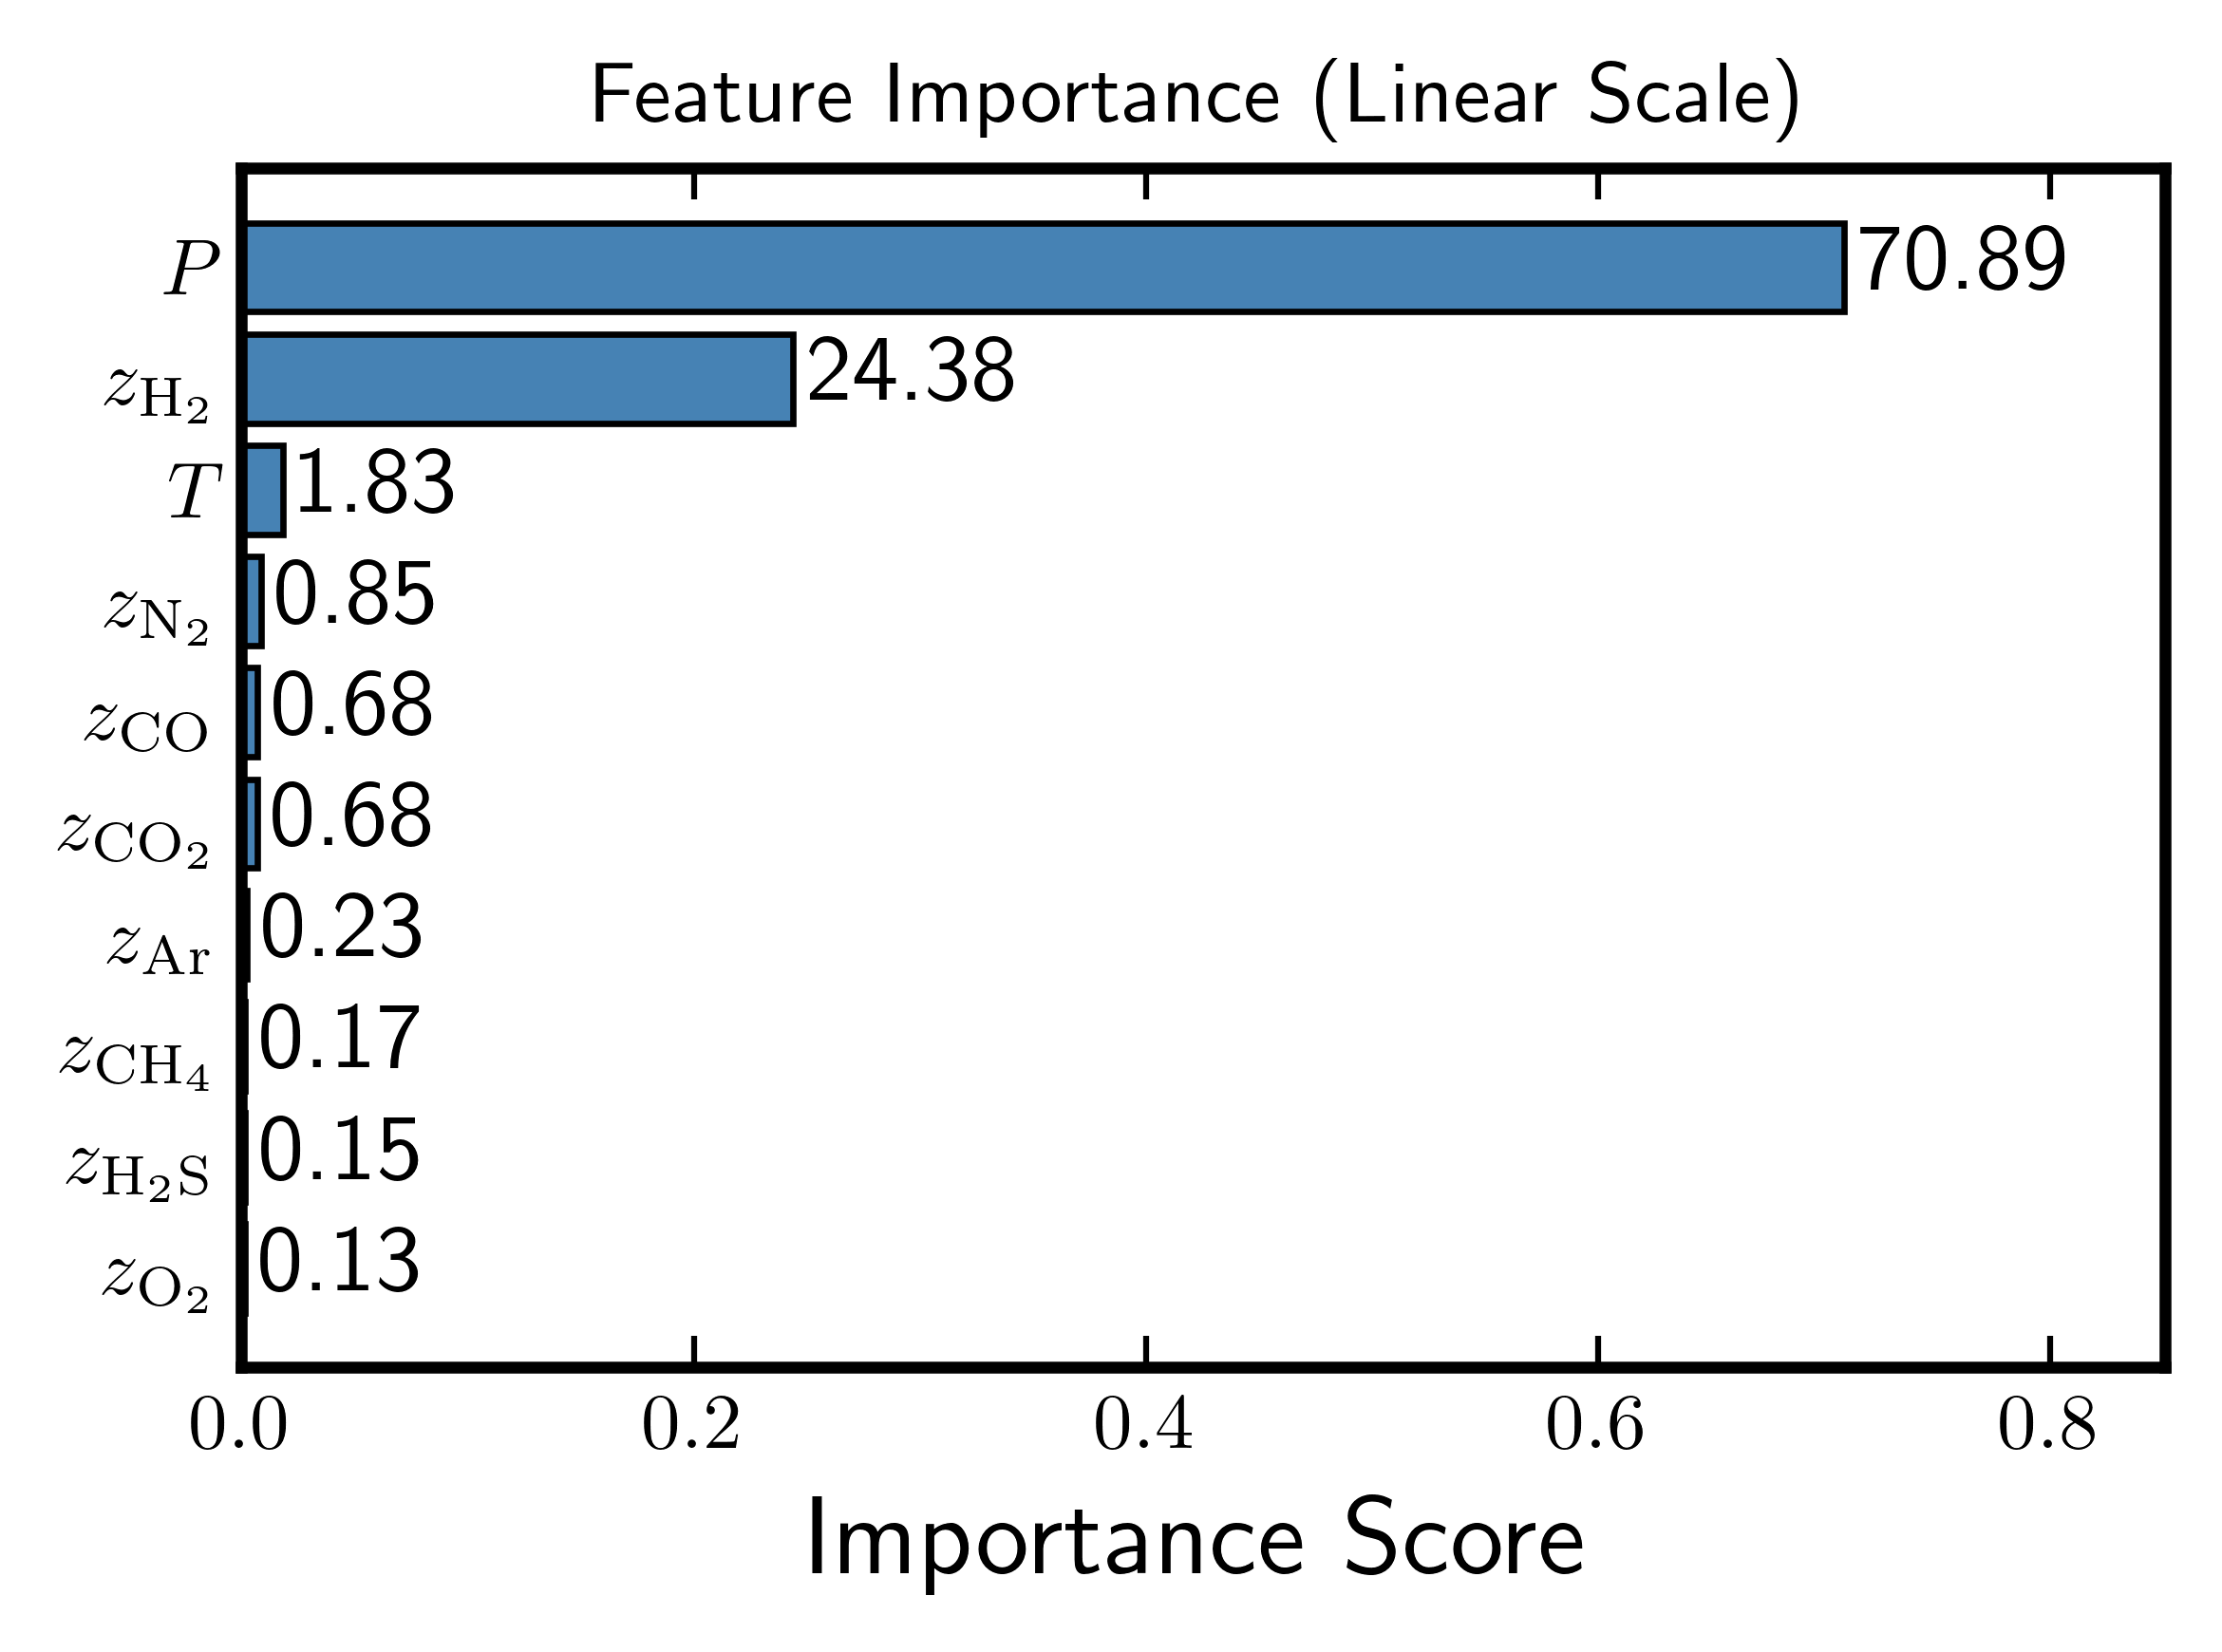

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [8]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_bubble",
    feature_importances=rf_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="RF_P_bubble_feature_importance_linear", folder=OUTPUT_FOLDER)

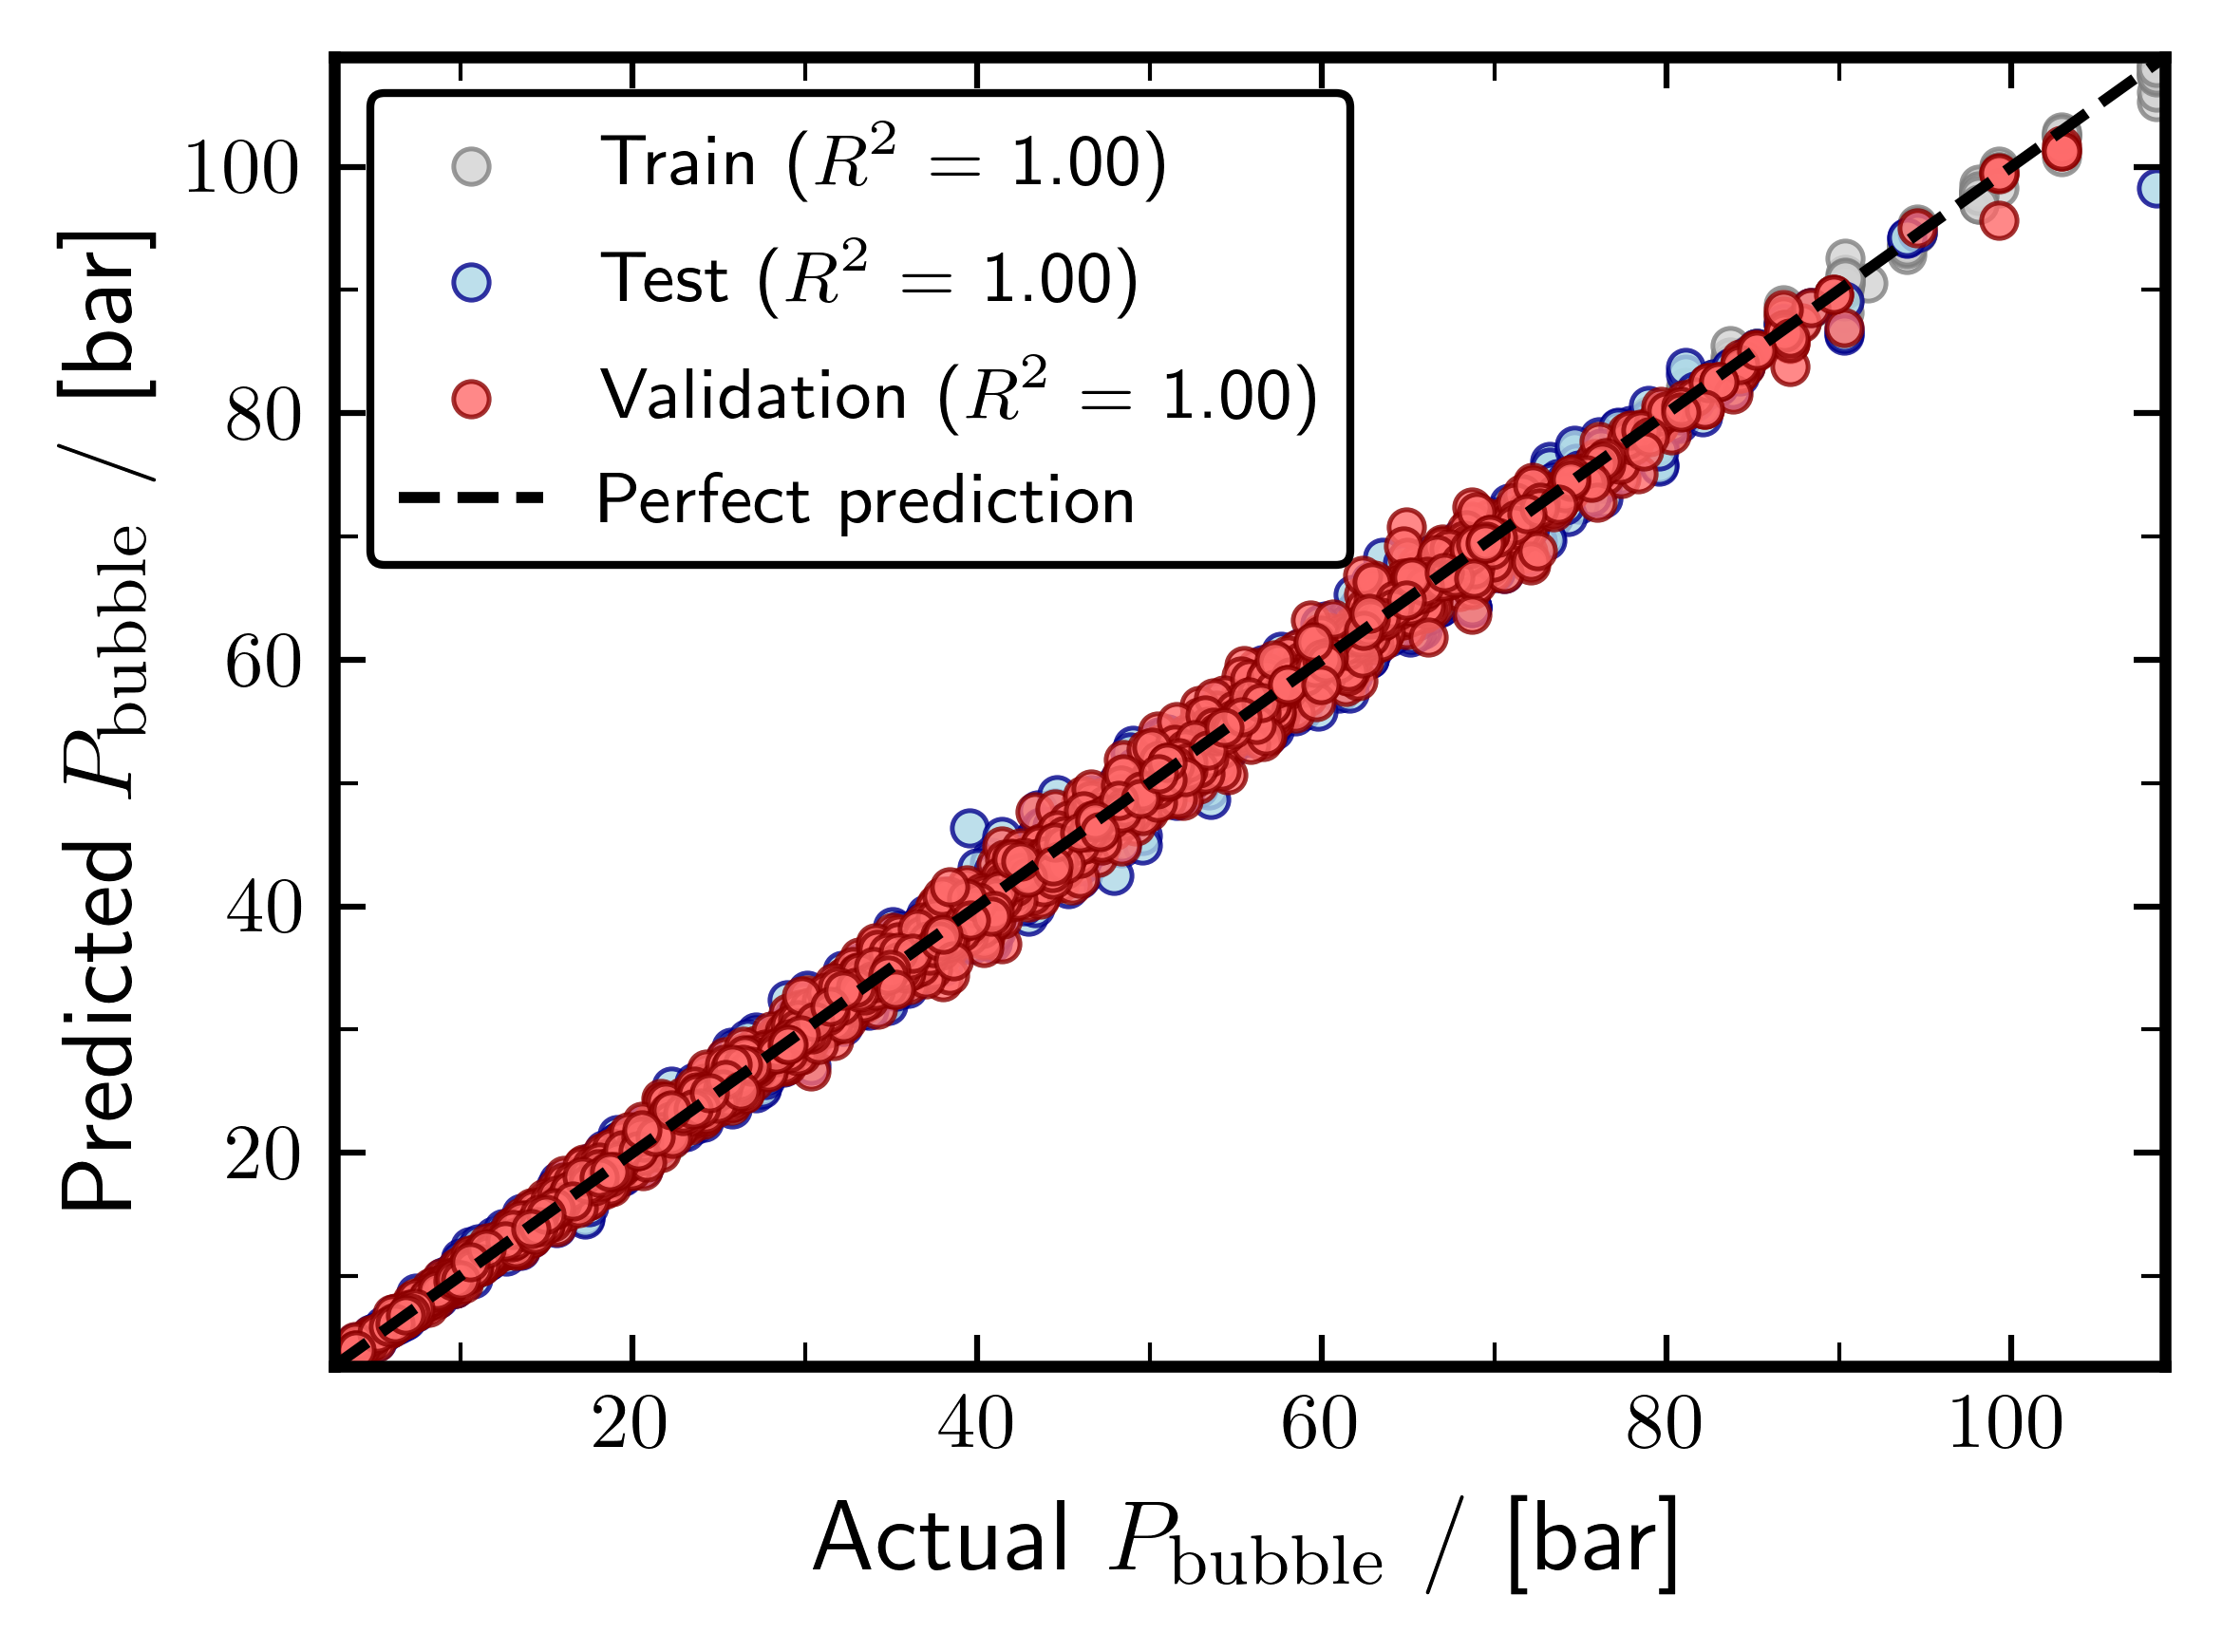

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]'>)

In [9]:
# Parity plot
post.plot_parity(model_name="Random Forest", save_path="RF_P_bubble_parity_plot", folder=OUTPUT_FOLDER,
                #  cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                 )

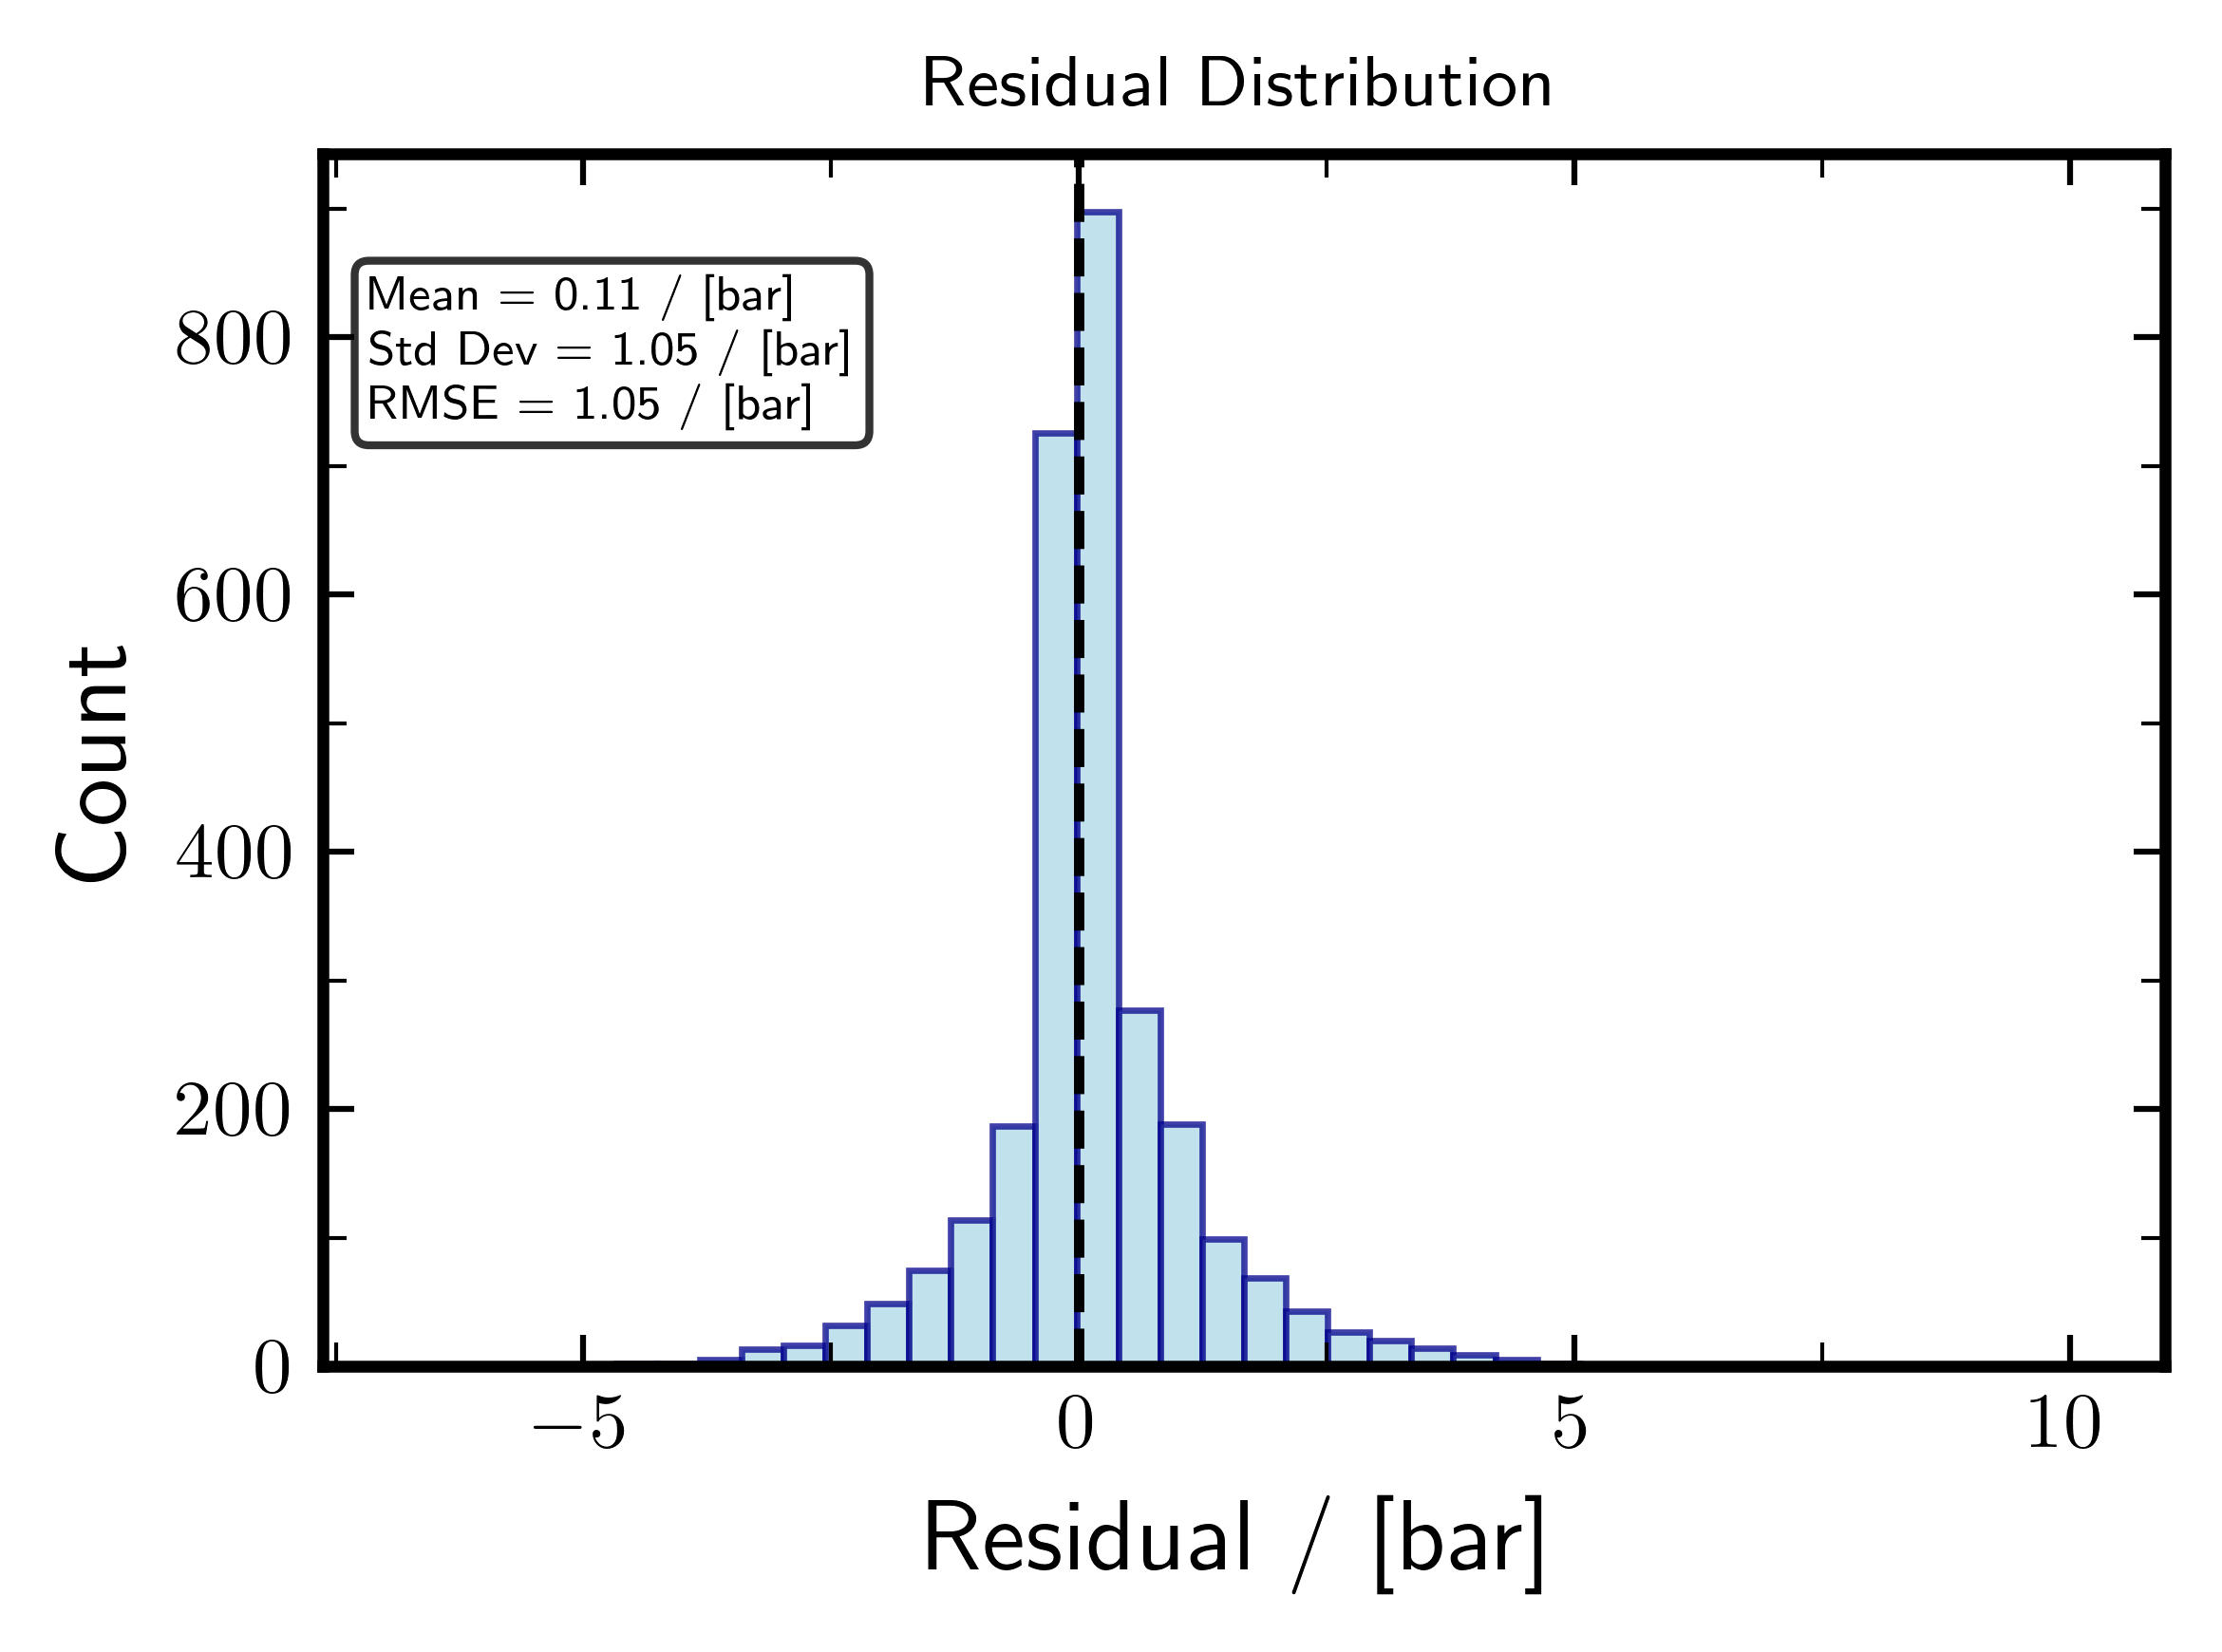

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution'}, xlabel='Residual / [bar]', ylabel='Count'>)

In [10]:
# Residual distribution
post.plot_residual_distribution(save_path="RF_P_bubble_residual_distribution", folder=OUTPUT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

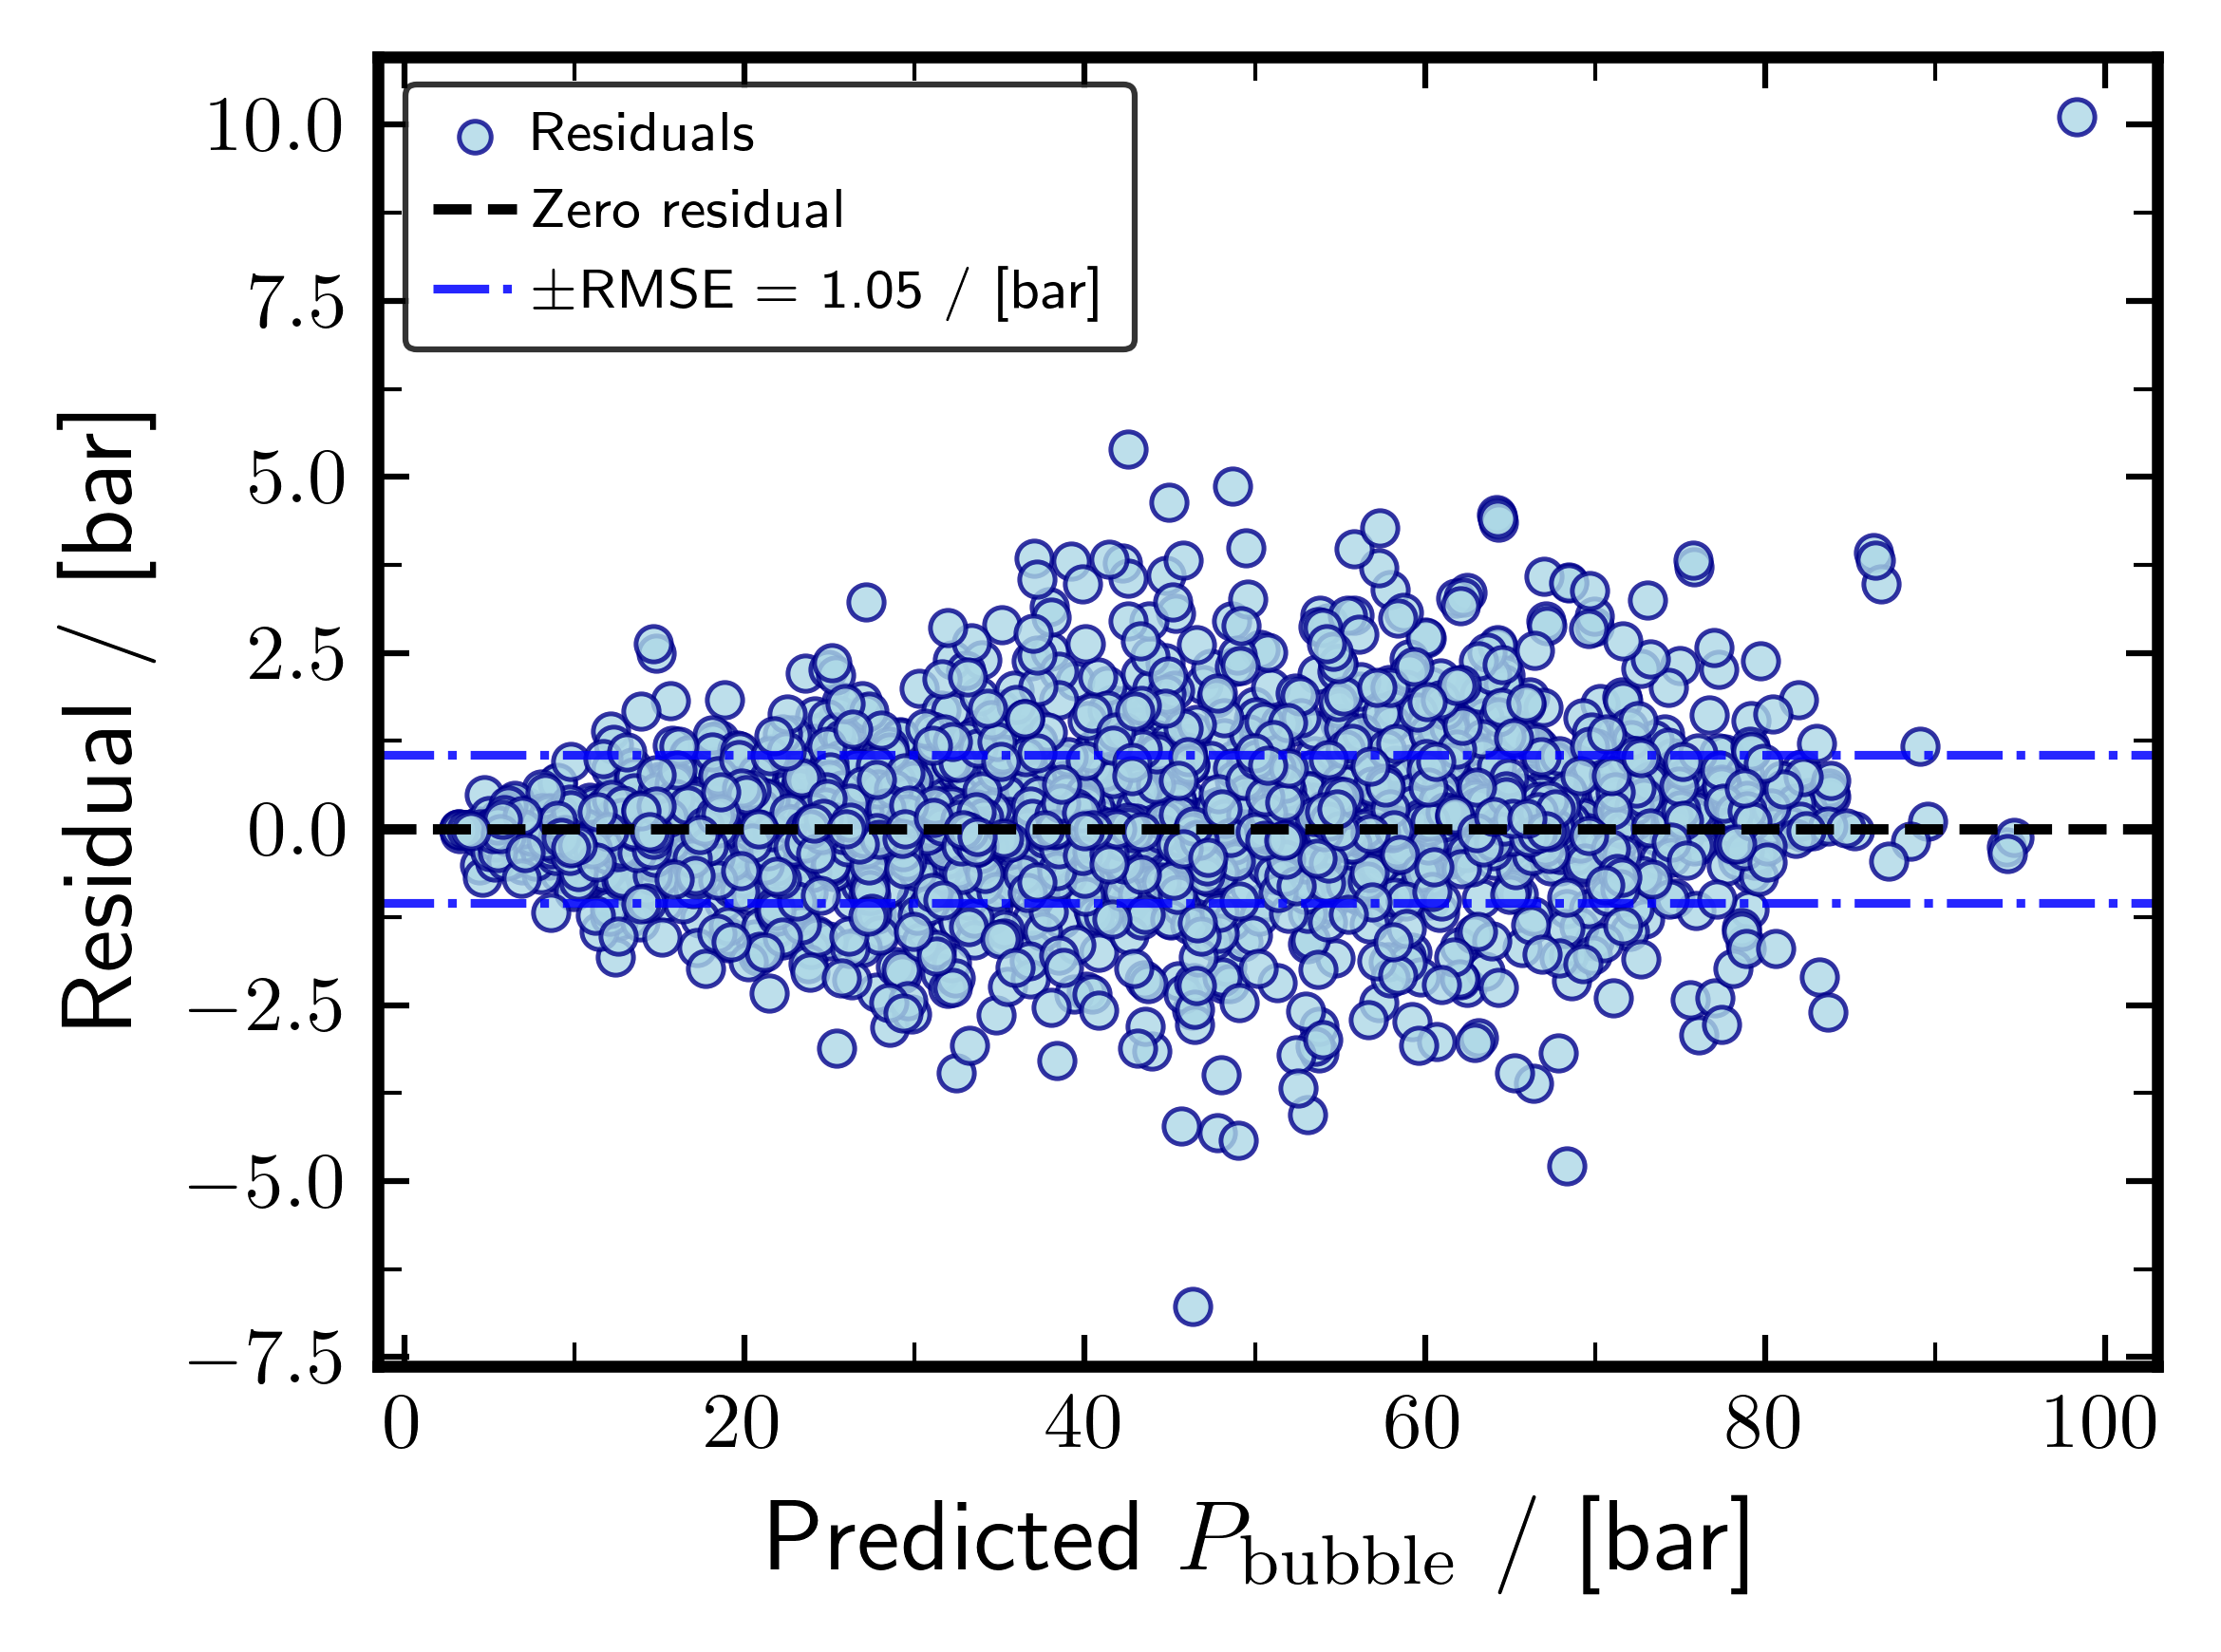

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{bubble}}$ / [bar]', ylabel='Residual / [bar]'>)

In [11]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="RF_P_bubble_residual_vs_predicted", folder=OUTPUT_FOLDER,
                                # cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean()
                                )

In [12]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["model"]           = "RandomForest"
metrics["n_estimators"]    = rf_model.n_estimators
metrics["max_depth"]       = rf_model.max_depth
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2876
R² Score:       0.997360
RMSE:           1.052246
MAE:            0.653385
Mean Residual:  0.111963
Std Residual:   1.046272

FEATURE IMPORTANCES:
------------------------------------------------------------
  pressure                  |  70.89% | ███████████████████████████████████
  z_hydrogen                |  24.38% | ████████████
  temperature               |   1.83% | 
  z_nitrogen                |   0.85% | 
  z_carbon monoxide         |   0.68% | 
  z_carbon dioxide          |   0.68% | 
  z_argon                   |   0.23% | 
  z_methane                 |   0.17% | 
  z_hydrogen sulfide        |   0.15% | 
  z_oxygen                  |   0.13% | 

Metrics saved to: RF_Pbubble_OUTPUTS/RF_P_bubble_metrics.json


In [14]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]  = cv_r2_scores.tolist()
metrics["cv_r2_mean"]    = float(cv_r2_scores.mean())
metrics["cv_r2_std"]     = float(cv_r2_scores.std())
metrics["model"]         = "RandomForest"
metrics["n_estimators"]  = rf_model.n_estimators
metrics["max_depth"]     = rf_model.max_depth
metrics["features"]      = features
metrics["target"]        = target
metrics["seed"]          = SEED

# Save metrics to JSON
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_BUBBLE
Samples:        2876
R² Score:       0.997360
RMSE:           1.052246
MAE:            0.653385
Mean Residual:  0.111963
Std Residual:   1.046272

FEATURE IMPORTANCES:
------------------------------------------------------------
  pressure                  |  70.89% | ███████████████████████████████████
  z_hydrogen                |  24.38% | ████████████
  temperature               |   1.83% | 
  z_nitrogen                |   0.85% | 
  z_carbon monoxide         |   0.68% | 
  z_carbon dioxide          |   0.68% | 
  z_argon                   |   0.23% | 
  z_methane                 |   0.17% | 
  z_hydrogen sulfide        |   0.15% | 
  z_oxygen                  |   0.13% | 

Metrics saved to: RF_Pbubble_OUTPUTS/RF_P_bubble_metrics.json


In [15]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.50 minutes
